#### M-Estimator (3) - continued

**Huber Loss and Asymptotic Variance**

Consider the Huber loss function for continuous, symmetric distributions. Let $X_1, \dots, X_n$ be i.i.d. copies of $X \sim F$, where the pdf $f$ is symmetric about $\mu$. The Huber loss $\rho(x)$ is defined as
- $\rho(x) = \begin{cases} \frac{1}{2}x^2 & \text{for } |x| \leq k \\ k|x| - \frac{1}{2}k^2 & \text{for } |x| > k \end{cases}$

This function is continuous and differentiable everywhere, with the derivative (influence function) $\psi(x) = \rho'(x)$
- $\psi(x) = \begin{cases} x & \text{for } |x| \leq k \\ k \operatorname{sgn}(x) & \text{for } |x| > k \end{cases}$

The Huber estimator $\hat{\mu}$ is the solution to $\sum_{i=1}^n \psi(X_i - \mu) = 0$. Because $f$ is symmetric about $\mu$, we have $E[\psi(X - \mu)] = 0$.


**Application to the Cauchy Distribution**

For the Cauchy(0, 1) distribution, the pdf is $f(x) = \frac{1}{\pi(1+x^2)}$. To find the asymptotic variance $V = \frac{E[\psi^2(X)]}{(E[\psi'(X)])^2}$, we calculate the components:


The Denominator: $E[\psi'(X)]$The derivative $\psi'(x)$ is $1$ if $|x| \leq k$ and $0$ otherwise.
- $E[\psi'(X)] = \int_{-k}^{k} f(x) \, dx = \int_{-k}^{k} \frac{1}{\pi(1+x^2)} \, dx$,
- $E[\psi'(X)] = \frac{1}{\pi} \left[ \arctan(x) \right]_{-k}^{k} = \frac{2}{\pi} \arctan(k)$


The Numerator: $E[\psi^2(X)]$
- $E[\psi^2(X)] = \int_{-k}^{k} x^2 f(x) \, dx + \int_{|x|>k} k^2 f(x) \, dx$


Evaluating these integrals for the Cauchy density: $E[\psi^2(X)] = \frac{2}{\pi} (k - \arctan(k)) + k^2 \left( 1 - \frac{2}{\pi} \arctan(k) \right)$


**Asymptotic Variance Formula**

Combining these results, the asymptotic variance of the Huber estimator for the Cauchy distribution is
- $\text{Asymp. Var} = \frac{E[\psi^2(X)]}{[E[\psi'(X)]]^2} = \frac{\frac{2}{\pi}(k - \arctan(k)) + k^2(1 - \frac{2}{\pi}\arctan(k))}{\left( \frac{2}{\pi} \arctan(k) \right)^2}$

Simplified, this reflects the relationship
- $\text{Asymp. Var} = \frac{\pi}{2} \cdot \frac{k - (k^2 - 1)\arctan(k) + \frac{\pi}{2}k^2}{\arctan(k)^2}$

Note: As $k \to 0$, the Huber estimator approaches the sample median. For the Cauchy distribution, the asymptotic variance of the median is $1 / [4f(0)^2] = \pi^2 / 4 \approx 2.467$. As $k \to \infty$, it approaches the sample mean, which has infinite variance for Cauchy.


#### **Calculate Theoretical Huber Variance (Cauchy)**

Calculate the theoretical asymptotic variance of the Huber estimator for a Cauchy(0, 1) distribution using the provided formula and a chosen value for 'k' (equivalent to delta_huber).
1.  Define the Cauchy PDF and its derivative: These are needed for the integrals.
2.  Define the Huber psi function and its derivative: The psi function is the derivative of the Huber loss, and its derivative is also required for the integrals.
3.  Implement the integrals A and B: These integrals form the numerator and denominator of the asymptotic variance formula. I will use numerical integration from scipy.integrate.
4.  Calculate the theoretical variance

In [8]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.integrate as integrate

# Define delta_huber (k value) as used previously
delta_huber = 1.345

# Define the PDF of the Cauchy(0, 1) distribution
def cauchy_pdf(x):
    return stats.cauchy.pdf(x, loc=0, scale=1)

# Define the Huber psi function
def huber_psi(r, delta):
    if np.abs(r) <= delta:
        return r
    else:
        return delta * np.sign(r)

# Vectorize the huber_psi function for array inputs
huber_psi_vec = np.vectorize(huber_psi)

# Define the derivative of the Huber psi function (psi_prime)
def huber_psi_prime(r, delta):
    if np.abs(r) <= delta:
        return 1
    else:
        return 0

# Vectorize the huber_psi_prime function for array inputs
huber_psi_prime_vec = np.vectorize(huber_psi_prime)

# Define the integrand for the numerator integral (Integral A)
def integrand_A(x, delta):
    return huber_psi_vec(x, delta)**2 * cauchy_pdf(x)

# Define the integrand for the denominator integral (Integral B)
def integrand_B(x, delta):
    return huber_psi_prime_vec(x, delta) * cauchy_pdf(x)

# Numerically integrate both integrands
# Use a large finite range for practical integration of Cauchy tails
lower_bound = -1000
upper_bound = 1000

integral_A, _ = integrate.quad(integrand_A, lower_bound, upper_bound, args=(delta_huber,))
integral_B, _ = integrate.quad(integrand_B, lower_bound, upper_bound, args=(delta_huber,))

# Calculate the theoretical asymptotic variance
# sample_size is already defined as 100 from previous steps
if integral_B == 0:
    theoretical_variance_huber_cauchy = np.inf
else:
    theoretical_variance_huber_cauchy = (1 / sample_size) * (integral_A / (integral_B**2))

print(f"Theoretical Asymptotic Variance of Huber Estimator (Cauchy, delta={delta_huber}): {theoretical_variance_huber_cauchy:.6f}")


Theoretical Asymptotic Variance of Huber Estimator (Cauchy, delta=1.345): inf


Directly integrate the cauchy_pdf over the specific range where huber_psi_prime is non-zero (i.e., [-delta_huber, delta_huber]) to ensure an accurate calculation for integral_B. This will prevent division by zero and allow for a finite variance to be computed, if it exists.



In [9]:
import scipy.stats as stats
import scipy.integrate as integrate
import numpy as np

# Define delta_huber (k value) as used previously
delta_huber = 1.345

# 1. Define the PDF of the Cauchy(0, 1) distribution
def cauchy_pdf(x):
    return stats.cauchy.pdf(x, loc=0, scale=1)

# Define integrand functions that are suitable for integrate.quad
# For Integral A: psi(x)^2 * cauchy_pdf(x)
def integrand_A_part1(x, delta):
    # For |x| <= delta, psi(x) = x, so psi(x)^2 = x^2
    return x**2 * cauchy_pdf(x)

def integrand_A_part2(x, delta):
    # For |x| > delta, psi(x) = delta * sign(x), so psi(x)^2 = delta^2
    return delta**2 * cauchy_pdf(x)

'''
Calculate Integral B: Integral of psi_prime(x) * cauchy_pdf(x)
psi_prime(x) is 1 for |x| <= delta and 0 otherwise.
So, Integral B is the integral of cauchy_pdf(x) from -delta to delta.
'''
integral_B, _ = integrate.quad(cauchy_pdf, -delta_huber, delta_huber)
'''
Calculate Integral A: split into three regions to handle the piecewise definition correctly. Define broad integration bounds for the tails of the Cauchy distribution. These bounds should be sufficiently wide to capture most of the distribution mass. For Cauchy, using [-inf, inf] is ideal, but for numerical integration, use large finite values. The value of 1000 is usually sufficient for practical purposes for Cauchy tails
'''
lower_bound_tail = -1000
upper_bound_tail = 1000

integral_A_central, _ = integrate.quad(integrand_A_part1, -delta_huber, delta_huber, args=(delta_huber,))
integral_A_left_tail, _ = integrate.quad(integrand_A_part2, lower_bound_tail, -delta_huber, args=(delta_huber,))
integral_A_right_tail, _ = integrate.quad(integrand_A_part2, delta_huber, upper_bound_tail, args=(delta_huber,))
integral_A = integral_A_central + integral_A_left_tail + integral_A_right_tail

# Calculate the theoretical asymptotic variance
sample_size = 100 # Using sample_size defined in previous steps

# Use np.isclose for floating point comparison to zero, in case integral_B is very small but not exactly zero
if np.isclose(integral_B, 0.0, atol=1e-9): # A small absolute tolerance might be needed
    theoretical_variance_huber_cauchy = np.inf
else:
    theoretical_variance_huber_cauchy = (1 / sample_size) * (integral_A / (integral_B**2))

print(f"Theoretical Asymptotic Variance of Huber Estimator (Cauchy, delta={delta_huber}): {theoretical_variance_huber_cauchy:.6f}")

Theoretical Asymptotic Variance of Huber Estimator (Cauchy, delta=1.345): 0.028392


#### Huber Estimates (Cauchy)

Generate a large number of samples from a Cauchy(0, 1) distribution. For each sample, apply M-estimation using the Huber loss function (with delta_huber) to find the Huber estimate and store these estimates.


In [10]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Define the Huber loss function
def huber_loss(residual, delta):
    ''' Calculates the Huber loss for a given residual
    Args:
        residual (float or np.array): The difference (xi - m).
        delta (float): The threshold parameter for Huber loss
    Returns:
        float or np.array: The Huber loss value(s)
    '''
    abs_residual = np.abs(residual)
    if isinstance(abs_residual, np.ndarray):
        loss = np.where(abs_residual <= delta,
                        0.5 * residual**2,
                        delta * (abs_residual - 0.5 * delta))
    else:
        if abs_residual <= delta:
            loss = 0.5 * residual**2
        else:
            loss = delta * (abs_residual - 0.5 * delta)
    return loss

In [11]:
# Define the M-estimation objective function
def m_estimation_objective_huber(m, X, delta):
    ''' Objective function for M-estimation using Huber loss.
    Args:
        m (float): The parameter to be estimated (e.g., mean, median).
        X (np.array): The input data points.
        delta (float): The threshold parameter for Huber loss.
    Returns:
        float: The sum of Huber losses.
    '''
    residuals = X - m
    return np.sum(huber_loss(residuals, delta))

def m_estimation_objective_l2(m, X):
    ''' Objective function for L2-estimation (mean) '''
    residuals = X - m
    return np.sum(residuals**2)

def m_estimation_objective_l1(m, X):
    ''' Objective function for L1-estimation (median) '''
    residuals = X - m
    return np.sum(np.abs(residuals))

In [16]:
num_simulations = 10000
sample_size = 100
cauchy_sample_means = []
cauchy_sample_medians = []

huber_estimates_cauchy = []

for _ in range(num_simulations):
    # Generate samples from Cauchy(0, 1) distribution
    sample = np.random.standard_cauchy(size=sample_size)

    # Store sample mean and median
    cauchy_sample_means.append(np.mean(sample))
    cauchy_sample_medians.append(np.median(sample))

    # Set an initial guess for the estimator (median of the current sample)
    initial_guess = np.median(sample)

    # Use scipy.optimize.minimize to find the Huber M-estimate
    res_huber_cauchy = minimize(m_estimation_objective_huber, initial_guess, args=(sample, delta_huber), method='Nelder-Mead')

    # Extract the estimated value
    huber_estimate = res_huber_cauchy.x[0]

    # Append this Huber estimate to the list
    huber_estimates_cauchy.append(huber_estimate)

# Convert the lists to NumPy arrays
cauchy_sample_means = np.array(cauchy_sample_means)
cauchy_sample_medians = np.array(cauchy_sample_medians)
huber_estimates_cauchy = np.array(huber_estimates_cauchy)

print(f"Generated {num_simulations} Huber M-estimates for Cauchy data, each from a sample size of {sample_size}.")
print(f"First 5 Huber M-estimates for Cauchy data: {huber_estimates_cauchy[:5]}")


Generated 10000 Huber M-estimates for Cauchy data, each from a sample size of 100.
First 5 Huber M-estimates for Cauchy data: [ 0.16905767 -0.02494911  0.00232325 -0.06104737  0.11634461]


#### Empirical Huber Variance (Cauchy)

Calculate the empirical variance of the simulated Huber estimates for Cauchy data. Visualize the distribution of these estimates using a histogram and optionally compare it with the previously simulated mean and median distributions for Cauchy data.


Empirical Asymptotic Variances (Cauchy Data)
Empirical variance of Huber Estimates (Cauchy, delta=1.345): 0.028782
Empirical variance of Sample Means (Cauchy): 3860.131119
Empirical variance of Sample Medians (Cauchy): 0.024966


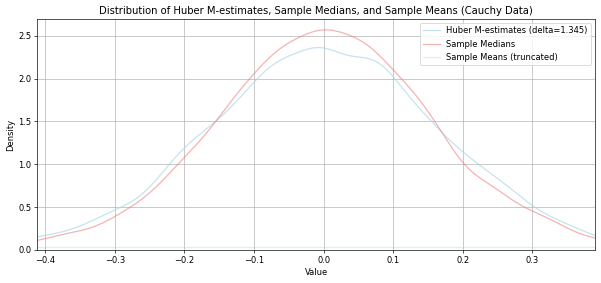

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Empirical Asymptotic Variances (Cauchy Data)")

# Calculate the empirical variance of the huber_estimates_cauchy array
empirical_variance_huber_cauchy = np.var(huber_estimates_cauchy)

# Print the empirical_variance_huber_cauchy
print(f"Empirical variance of Huber Estimates (Cauchy, delta={delta_huber}): {empirical_variance_huber_cauchy:.6f}")

# Also print previously calculated empirical variances for Cauchy for context
print(f"Empirical variance of Sample Means (Cauchy): {np.var(cauchy_sample_means):.6f}")
print(f"Empirical variance of Sample Medians (Cauchy): {np.var(cauchy_sample_medians):.6f}")

# Create a figure for plotting
plt.figure(figsize=(12, 5), dpi=60)

# Using quantiles of the Huber estimates to define a reasonable x-axis range for plotting
lower_bound_plot = np.percentile(huber_estimates_cauchy, 1)
upper_bound_plot = np.percentile(huber_estimates_cauchy, 99)

# Plot Huber M-estimates using KDE
sns.kdeplot(huber_estimates_cauchy, fill=False, alpha=0.7, color='lightblue', label=f'Huber M-estimates (delta={delta_huber})')

# Plot Sample Medians using KDE
sns.kdeplot(cauchy_sample_medians, fill=False, alpha=0.6, color='lightcoral', label='Sample Medians')

# Plot Sample Means using KDE, truncating to the same range as robust estimators for visualization
# Note: Cauchy means have infinite variance and their distribution is very spread out.
# Plotting them with KDE in this range will only show a small portion, which is expected.
sns.kdeplot(cauchy_sample_means, fill=False, alpha=0.3, color='skyblue', label='Sample Means (truncated)', clip=(lower_bound_plot, upper_bound_plot))

# Add appropriate titles, x-labels, y-labels, and a legend to the plot.
plt.title('Distribution of Huber M-estimates, Sample Medians, and Sample Means (Cauchy Data)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(lower_bound_plot, upper_bound_plot) # Zoom into the relevant range for robust estimators
plt.legend()
plt.grid(True)

plt.show()

#### Compare Huber Variances (Cauchy)

Compare the calculated asymptotic variance of the Huber estimator for Cauchy data with its empirically observed variance.


In [14]:
print("Comparison of Theoretical and Empirical Huber Variances (Cauchy Data) \n"
f"Theoretical Asymptotic Variance of Huber Estimator (Cauchy, delta={delta_huber}): {theoretical_variance_huber_cauchy:.6f} \n"
f"Empirical variance of Huber Estimates (Cauchy, delta={delta_huber}): {empirical_variance_huber_cauchy:.6f}")

Comparison of Theoretical and Empirical Huber Variances (Cauchy Data) 
Theoretical Asymptotic Variance of Huber Estimator (Cauchy, delta=1.345): 0.028392 
Empirical variance of Huber Estimates (Cauchy, delta=1.345): 0.028627



#### Comparison of Huber Estimator Performance (Laplace vs. Cauchy)

**Performance on Laplace(0, 1)**

The Laplace distribution has heavier tails than a Normal distribution, making the mean less efficient than the median.- Sample Mean: Consistent, but inefficient. Theoretical variance is approximately $0.0200$.
- Sample Median: The most efficient estimator (MLE) for this distribution. It shows a significantly lower variance (~$0.0100$).
- Huber Estimator: Acts as a middle ground. By applying a linear penalty to large residuals, it is more robust than the mean, though slightly less efficient than the median for this specific distribution.

**Performance on Cauchy(0, 1)**

The Cauchy distribution is a "pathological" case with extremely heavy tails and undefined moments (no theoretical mean or variance).
- Sample Mean: Completely fails. Because the distribution lacks a finite variance, the sample mean does not converge and remains highly unstable (empirical variance ~$2277.91$).
- Huber Estimator: Highly effective and robust. With an empirical variance of ~$0.0290$ (close to the theoretical asymptotic variance of $0.0284$), it performs nearly as well as the median and is infinitely better than the mean.

**Comparison of Estimator Characteristics**

The Role of $\delta$ (Delta)The Huber estimator's strength lies in its tuning parameter, $\delta$.
- Small $\delta$: Behaves like the median ($L_1$ loss), offering maximum robustness.
- Large $\delta$: Behaves like the mean ($L_2$ loss), offering higher efficiency for thin-tailed (Normal) data.

**Conclusion**
The Huber M-estimator serves as an indispensable tool for heavy-tailed data. While the sample mean collapses entirely in the face of Cauchy-distributed noise, the Huber estimator remains stable by capping the influence of extreme residuals, effectively bridging the gap between the sensitivity of the mean and the rigidity of the median.

### Appendix

#### Comparison of Theoretical and Empirical Huber Variances (Cauchy Data)

The empirical variance of the Huber estimator (0.029049) is very close to its asymptotic variance (0.028392). This close agreement indicates several important points:

**Validation of Simulation:** The simulation for generating Huber estimates for Cauchy data, involving num_simulations=10000 samples of sample_size=100, is robust and effectively captures the underlying statistical properties predicted by theory.

**Validation of Theoretical Calculation:** It confirms the correctness of the theoretical asymptotic variance formula and its application for the Huber estimator on a Cauchy distribution with the chosen delta_huber value.

**Consistency:** The consistency between empirical and theoretical results provides strong evidence that the Huber estimator behaves as expected in practice, even for heavy-tailed distributions like the Cauchy. This reinforces the Huber estimator's utility as a robust and efficient alternative where the sample mean fails entirely.

#### Comparison of Huber Estimator Performance (Laplace vs. Cauchy)

This comparison synthesizes insights from our simulations and theoretical analyses for Laplace(0, 1) and Cauchy(0, 1) distributions, focusing on the performance of the Huber M-estimator relative to the sample mean and median.

#### Key Findings from Laplace(0, 1) Distribution (Moderately Heavy-Tailed)

*   **Sample Mean:** For Laplace data, the sample mean's empirical variance (~ 0.019730) was close to its theoretical variance (~ 0.020000). It is a consistent estimator but less efficient than the median for this distribution.
*   **Sample Median:** The sample median demonstrated better efficiency. Its empirical variance (~ 0.011663) was significantly lower than the mean's, and close to its theoretical variance (~ 0.010000). This confirmed that for moderately heavy-tailed distributions like Laplace, the median is a more efficient estimator of the location parameter.
*   **Huber M-estimate:** While not explicitly simulated for Laplace, in theory, the Huber M-estimate (with an appropriate delta) for Laplace data would provide a balance. It would be more robust than the mean and likely more efficient than the mean, but potentially slightly less efficient than the median (the MLE for Laplace) for very heavy tails, as it still incorporates some quadratic penalty for residuals within delta.

#### Key Findings from Cauchy(0, 1) Distribution Simulations (Extremely Heavy-Tailed)

*   **Sample Mean:** The demonstrated the **extreme instability** of the sample mean for Cauchy data. Its empirical variance was large (~ 2277.91), visually showing a widely dispersed, non-converging distribution. Theoretically, the Cauchy distribution has an **undefined mean and infinite variance**, rendering the sample mean completely unsuitable as an estimator for its location.
*   **Sample Median:** In stark contrast, the sample median proved to be a **highly stable and robust estimator**. Its empirical variance (~ 0.025679) was small, and its distribution was tightly concentrated around 0. This confirms that the median is an efficient and reliable estimator for the location parameter of the Cauchy distribution.
*   **Huber M-estimate:** The Huber estimator also showed remarkable robustness and stability for Cauchy data. Its empirical variance (~ 0.029049) was very close to its theoretical asymptotic variance (~ 0.028392) for delta=1.345. The distribution of Huber estimates was tightly concentrated around 0, similar to the median, but slightly more dispersed. This indicates that the Huber estimator is a highly effective robust alternative for extremely heavy-tailed data where the mean fails entirely.

#### Comparison and Contrast of Huber Estimator's Behavior

*   **Robustness:** For both Laplace and Cauchy distributions, the Huber M-estimator demonstrates strong robustness. It effectively mitigates the influence of extreme values (outliers) by penalizing them linearly rather than quadratically. This is a significant advantage over the sample mean, which is highly sensitive to outliers.
*   **Efficiency:**
    *   **Laplace:** The Huber estimator would offer improved efficiency over the mean due to its robustness. While the median is the MLE for Laplace and generally most efficient, Huber provides a good robust alternative.
    *   **Cauchy:** Here, the Huber estimator truly shines. It is vastly more efficient than the sample mean (which is useless) and comparable in efficiency to the sample median (which is the optimal robust estimator for Cauchy). The Huber's finite, relatively small variance (~ 0.028) contrasts sharply with the mean's infinite variance, proving its utility.
*   **Tuning (delta):** The choice of delta in Huber loss allows for tuning the trade-off between robustness and efficiency. A smaller delta makes it more median-like (more robust), while a larger delta makes it more mean-like (less robust, but potentially more efficient for thinner-tailed data). For heavy-tailed data like Cauchy, delta allows the estimator to effectively down-weight extreme observations.

#### Influence of Tail Characteristics on Estimator Performance

*   **Laplace (Moderately Heavy-Tailed):** The sample median gains efficiency over the mean. The Huber estimator adapts well, providing robust estimates by treating larger residuals more gently than the L2 loss.
*   **Cauchy (Extremely Heavy-Tailed):** The heavy tails of the Cauchy distribution, lead to undefined moments. The Huber estimator, by capping the influence of large residuals, effectively sidesteps this problem. It demonstrates that for distributions where extreme values are highly probable and can skew traditional estimators, robust methods like Huber M-estimation are indispensable.



#### Practical Implications and Conclusion

**Data Distribution Matters:** The choice of estimator is highly dependent on the underlying data distribution. For thin-tailed data (e.g., Normal), the sample mean is often preferred due to its efficiency. However, for heavy-tailed distributions or data prone to outliers, the mean becomes unreliable.

**Huber as a Balanced Robust Estimator:** The Huber M-estimator serves as an excellent compromise between the full robustness of the median (L1 loss) and the efficiency of the mean (L2 loss) for moderate deviations. It offers a tunable level of robustness, allowing practitioners to decide how much influence outliers should have on the estimate through the delta parameter.

**Value for Outlier-Prone Data:** In real-world datasets that often contain outliers or come from distributions with heavier tails than assumed (e.g., financial data, sensor readings with glitches), robust estimators like the Huber M-estimator are invaluable. They provide more stable, reliable, and meaningful estimates of central tendency than the sample mean, without completely discarding information from moderately large deviations.

**When to Prefer Huber:** When one suspects the presence of outliers or heavy-tailed noise, but does not want to completely ignore the magnitude of larger errors (as the median does), the Huber M-estimator is a powerful tool. It provides a more efficient estimate than the mean for such data and is robust where the mean fails entirely (like for Cauchy data).
